# Batch correction, Clustering, Phenotyping

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import seaborn as sns
import warnings

from inmoose.pycombat import pycombat_norm, pycombat_seq

In [13]:
def make_umap(X):
    from umap import UMAP
    embedding = (
        UMAP(random_state=5, n_neighbors=20, min_dist=0.0005, repulsion_strength=1.5)
        .fit_transform(X)
    )
    return embedding

def cluster_cells(X, nclus=40, random_state=0):

    from sklearn.cluster import MiniBatchKMeans, DBSCAN
    from sklearn.feature_extraction.text import TfidfVectorizer
    
    #MiniBatch K-Means for large datasets
    kmeans = MiniBatchKMeans(n_clusters=nclus, batch_size=1000, max_iter=500, random_state=random_state)
    
    kmeans.fit(X)
    
    #get labels
    labels = kmeans.labels_
    labels_str = [str(i) for i in labels]
    
    distances = np.linalg.norm(X - kmeans.cluster_centers_[labels], axis=1)

    return labels_str
    
def knn_psuedobulk(X, nclus=100, random_state=0):
    import numpy as np
    from sklearn.cluster import MiniBatchKMeans
    
    # MiniBatch K-Means for large datasets
    kmeans = MiniBatchKMeans(n_clusters=nclus, batch_size=1000, max_iter=500, random_state=random_state)
    kmeans.fit(X)

    labels = kmeans.labels_
    labels_str = [str(i) for i in labels]
    
    cluster_centers = kmeans.cluster_centers_
    
    return cluster_centers, labels_str

def marker_capping(x, perc = 99):
    x_perc = np.percentile(x, perc)
    return np.where(x > x_perc, x_perc, x) 

## Import

In [ ]:
adata = sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/in/full_data-no_uns.h5ad') #`.uns['spatial']` removed
adata

In [15]:
# Prep for clustering, essentials only

adata.X = adata.layers['compcounts'].copy()
for i in ['compcounts', 'compexprs', 'exprs']:
    del adata.layers[i]

In [16]:
adata.obs.major_cell_type.value_counts()

major_cell_type
Myeloid         747350
Myeloma         182547
T               159867
B-T              77306
Unclassified     63030
ECs              47214
B cells          38253
NK cells         27236
Adipocyte        25312
MKs              25282
Artifact          8721
MDSC              7824
Name: count, dtype: int64

## Normalisation and correction choices

In [17]:
# Remove adipo, null expression confuses
adata = adata[adata.obs.major_cell_type!='Adipocyte',]

In [18]:
# Total signal, log1p
adata.obs['log1p_totalsignal'] = np.log1p(adata.X.sum(axis=1))

In [21]:
# 0-aware norm

#'log1p(X+1/log1p_totalsignal)'
adata.layers['Xpc_totsig_log1p_combat'] = pycombat_norm(
    np.log1p(
        pd.DataFrame(
            pd.DataFrame(adata.X).fillna(0).values.T+1)\
                .div(adata.obs['log1p_totalsignal'].tolist(), axis=1)
    ),
    adata.obs.cohort).T

In [22]:
adata

AnnData object with n_obs × n_vars = 1384630 × 36
    obs: 'area', 'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'Cell_ID', 'library_id', 'sample_id', 'ObjectNumber', 'width_px', 'height_px', 'major_celltype', 'major_cell_type', 'minor_cell_type', 'Ki-67_minor_cell_type', 'PD-L1_minor_cell_type', 'PD-1_minor_cell_type', 'pSTAT1_minor_cell_type', 'TIM-3_minor_cell_type', 'tissue_id', 'slide_id', 'timepoint', 'patient_n', 'DFCI_id', 'MRN', 'medium_cell_type', 'Ki-67_medium_cell_type', 'PD-L1_medium_cell_type', 'PD-1_medium_cell_type', 'pSTAT1_medium_cell_type', 'TIM-3_medium_cell_type', 'functional_minor_cell_type', 'functional_cell_type', 'cohort', 'batch', 'ROI', 'log1p_totalsignal'
    obsm: 'spatial'
    layers: 'X_combat', 'log1p_X_combat', 'Xpc_totsig_log1p_combat'

## Clustering: all cells

In [23]:
adata.n_obs

1384630

In [24]:
# new filter: minimum signal
#sns.histplot(adata.obs['log1p_totalsignal'])
log1p_totalsignal__thr = 2.5 #confirmed on umap
adata = adata[adata.obs['log1p_totalsignal']>log1p_totalsignal__thr]

In [25]:
adata.n_obs

1339729

In [27]:
1384630-1339729
44901/1384630

0.032428157702779806

In [13]:
# Expression prep

marker_fun = ['aSMA','CD14','CD16','CD163','CD11b','CD31','CD45','CD4','CD68','CD20','CD8','CD56','CD138','Granzyme_B','CD3','CD45RO']

adata.layers['Xpc_totsig_log1p_combat_scaled'] = sc.pp.scale(adata.layers['Xpc_totsig_log1p_combat'])
adata.obsm['Xpc_totsig_log1p_combat_scaled'] = adata[:,marker_fun].layers['Xpc_totsig_log1p_combat_scaled']

In [ ]:
## KNN pseudobulk approach

In [231]:
exp, cell2clus = knn_psuedobulk(adata.obsm['Xpc_totsig_log1p_combat_scaled'], nclus=5000)

In [385]:
pd.Series(cell2clus).to_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-allcells.csv')

In [278]:
adata.obs['cell2clus'] = cell2clus

In [234]:
import anndata as ad

adata_pb = ad.AnnData(X=exp, obs=pd.DataFrame(index=list(range(len(np.unique(cell2clus))))))
adata_pb.var =  adata[:,marker_fun].var.copy()
adata_pb

AnnData object with n_obs × n_vars = 5000 × 16

In [235]:
sc.pp.neighbors(adata_pb,random_state=12345)
sc.tl.leiden(adata_pb)
sc.tl.leiden(adata_pb, resolution=2, key_added='leiden_2')
adata_pb.obsm['X_umap'] = make_umap(adata_pb.X)

In [296]:
cell2clus_cohort = adata.obs[['cell2clus','cohort']].value_counts().reset_index()\
.pivot(index='cell2clus',columns='cohort',values='count').fillna(0).rename_axis(None)
cell2clus_cohort['prop_og'] = cell2clus_cohort['og']/(cell2clus_cohort['og']+cell2clus_cohort['validation'])

adata_pb.obs = adata_pb.obs.join(cell2clus_cohort[['prop_og']])

In [236]:
adata_pb.obs = adata_pb.obs.join(pd.Series(cell2clus).value_counts())
adata_pb.obs['log10_count'] = np.log10(adata_pb.obs['count'])

In [305]:
adata_pb.obs = adata_pb.obs.join(adata.obs[['cell2clus','log1p_totalsignal']].groupby('cell2clus').mean())

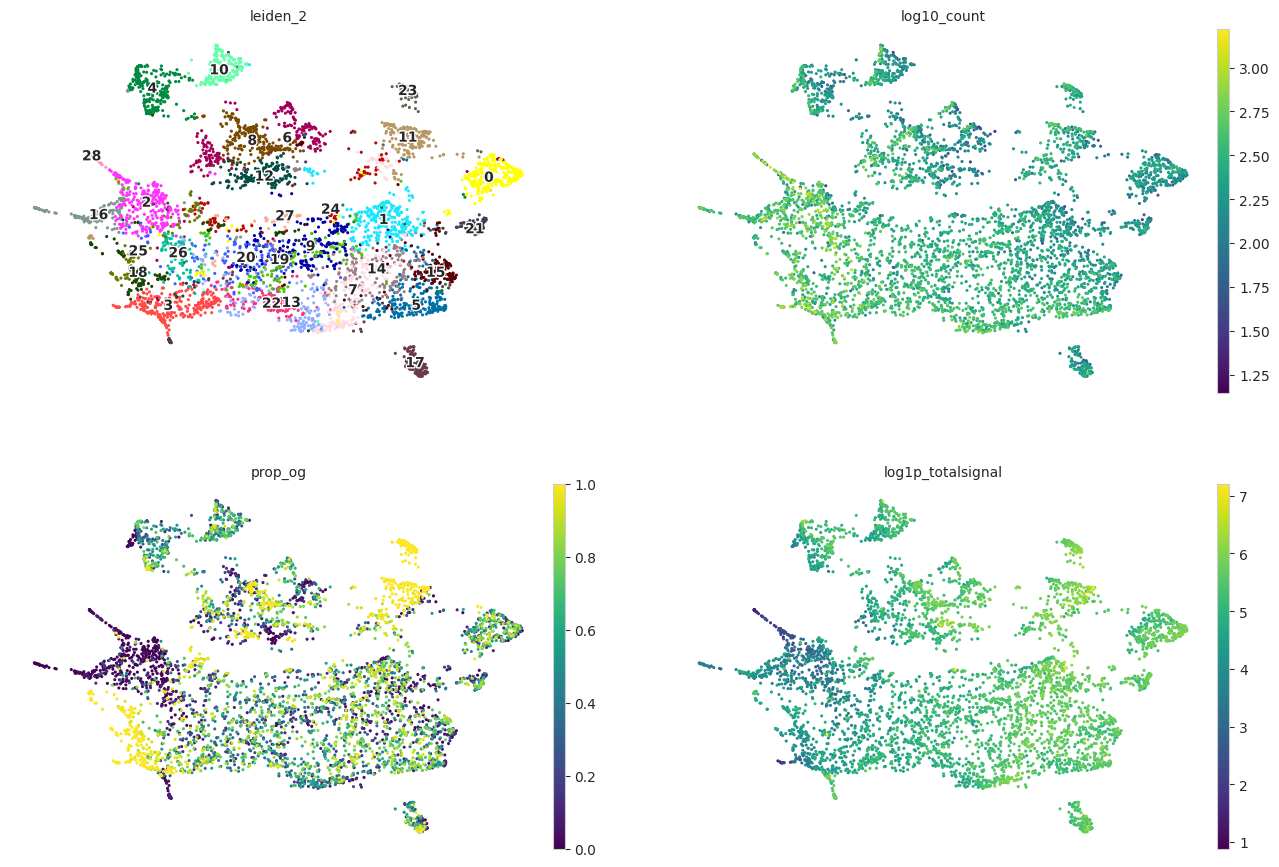

In [306]:
with rc_context({"figure.figsize": (7,5),"axes.titlesize": 10}):
    sc.pl.umap(adata_pb, color=['leiden_2','log10_count','prop_og','log1p_totalsignal'], legend_loc='on data', layer='X_scaled', 
        cmap='viridis', legend_fontsize=10, legend_fontoutline=2, frameon=False, s=20, ncols=2)

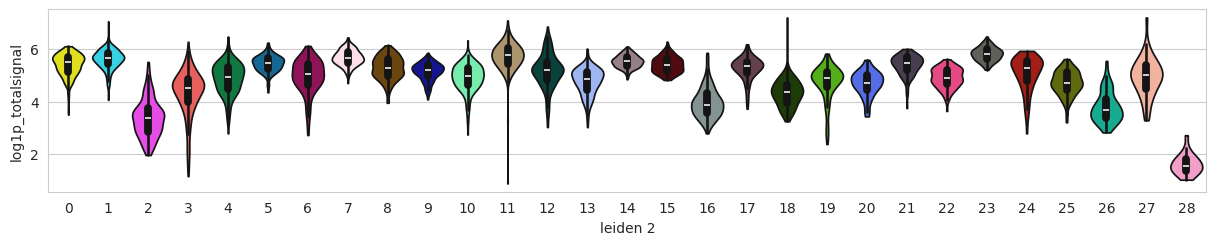

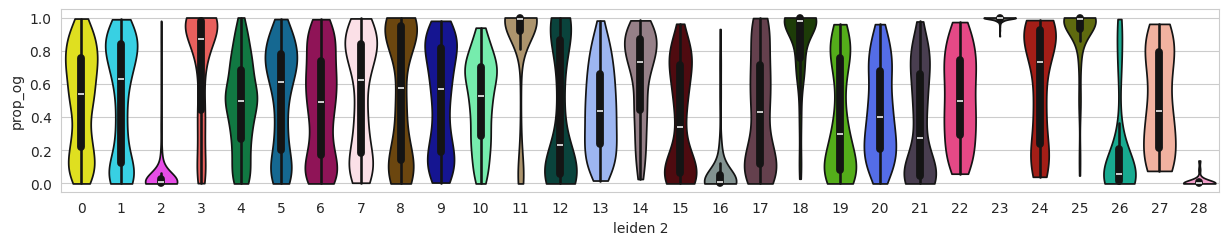

In [314]:
# vln signal/batch

clus_='leiden_2'
with rc_context({"figure.figsize": (12, 2.5)}):
    sc.pl.violin(adata_pb,['log1p_totalsignal'],groupby=clus_,stripplot=False,inner="box")
    sc.pl.violin(adata_pb,['prop_og'],groupby=clus_,stripplot=False,inner="box")

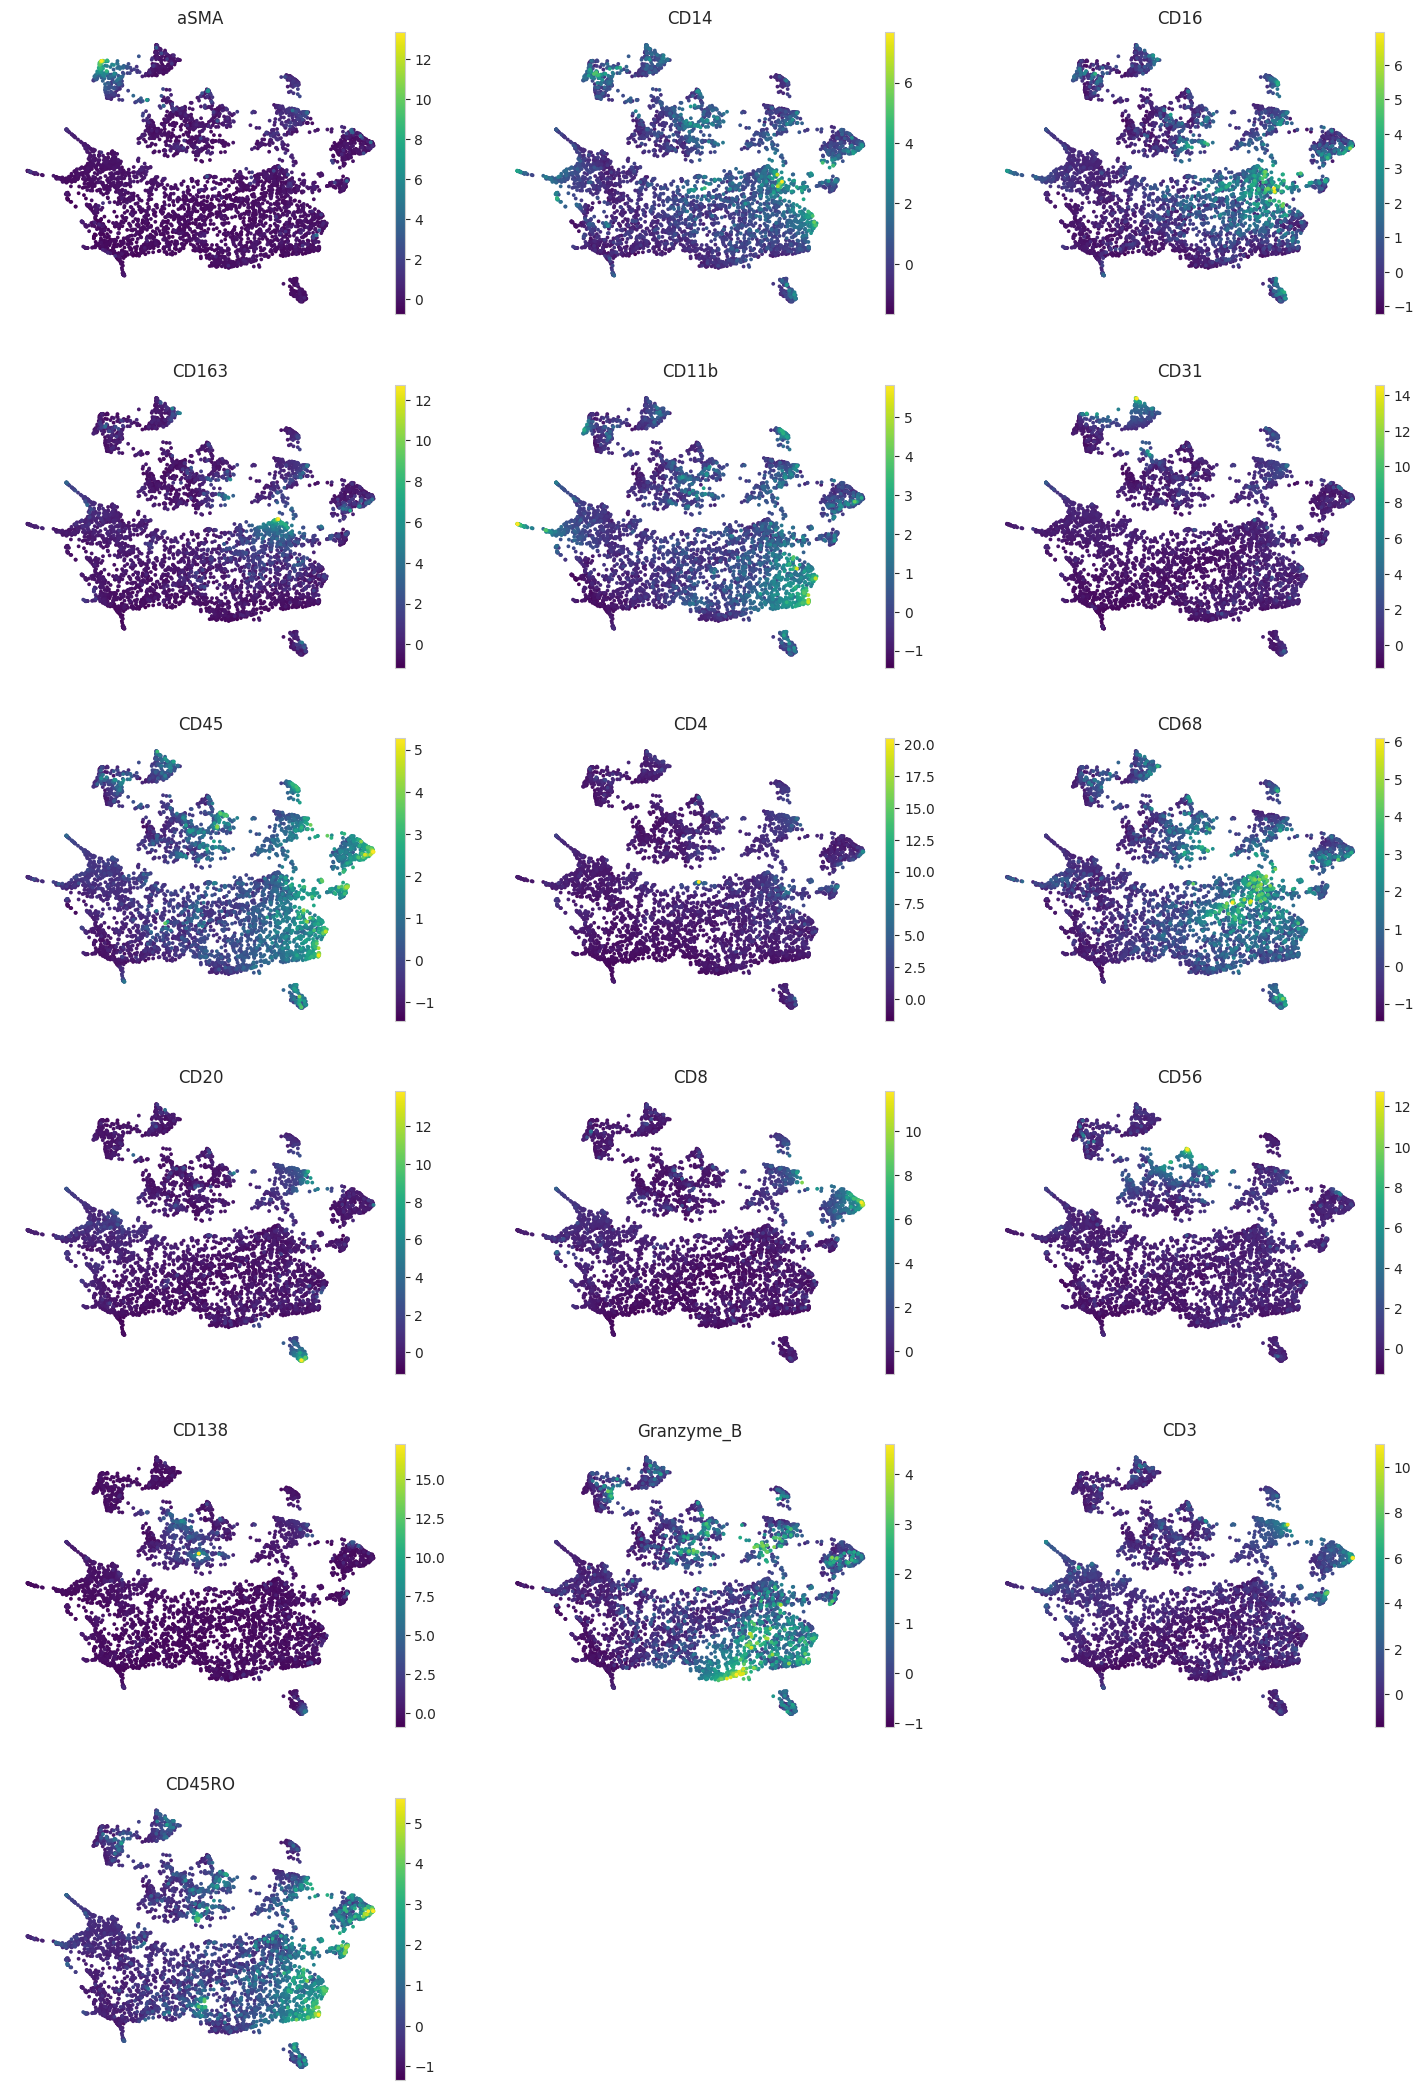

In [276]:
# Pheno umap

with rc_context({"figure.figsize": (5,4),"axes.titlesize": 12}):
    sc.pl.umap(adata_pb, color=marker_fun, legend_loc='right', legend_fontsize=10, legend_fontoutline=2, 
               cmap='viridis', frameon=False, s=30, ncols=3)

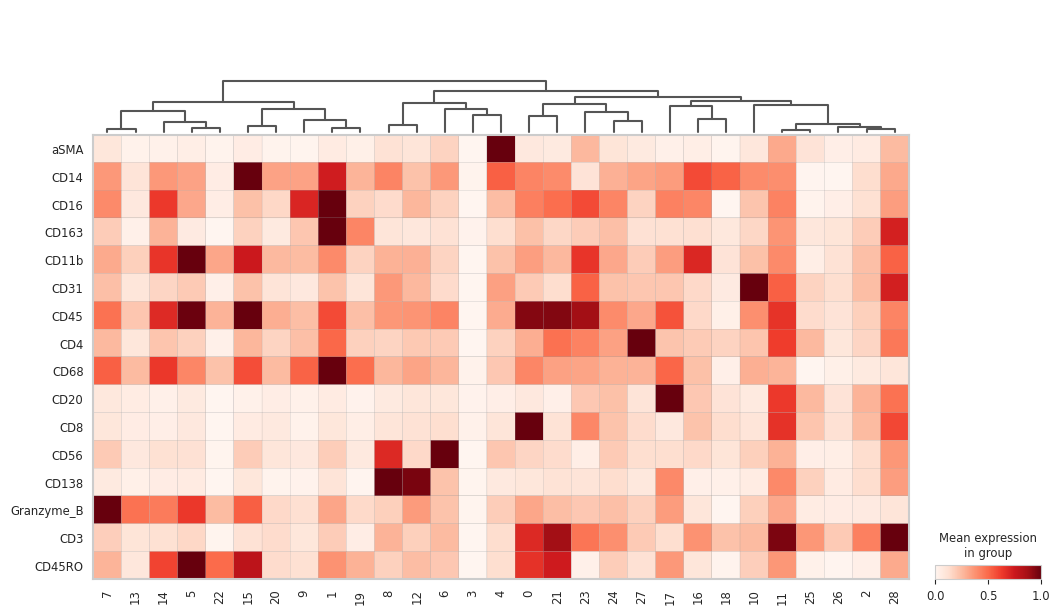

In [316]:
# Pheno hm
clus_='leiden_2'
sc.pl.matrixplot(adata_pb, marker_fun, clus_, dendrogram=True, cmap="Reds",swap_axes=True,standard_scale='var')

In [ ]:
# Import labels

In [14]:
labels = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/pheno-allcells.csv')
labels.leiden_2=labels.leiden_2.astype(str)

In [342]:
adata_pb.obs = adata_pb.obs.drop(['lineage','pheno','notes'],axis=1)

In [346]:
adata_pb.obs = adata_pb.obs.merge(labels)

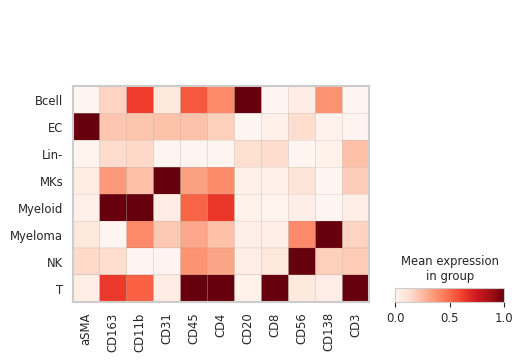

In [389]:
# Pheno hm, no QC
clus_='leiden_2'
marker_fun2 = ['aSMA','CD163','CD11b','CD31','CD45','CD4','CD20','CD8','CD56','CD138','CD3']
sc.pl.matrixplot(adata_pb[adata_pb.obs.lineage!='B-T'], 
                 marker_fun2, 'lineage', dendrogram=False, cmap="Reds",swap_axes=False,standard_scale='var')

In [521]:
adata_pb.write('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-allcells.h5ad',compression='gzip')

## Import

In [17]:
adata.obs['cell2clus'] = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-allcells.csv',index_col=0).astype(str).iloc[:,0].tolist()

In [18]:
adata_pb = sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-allcells.h5ad')

In [19]:
labels = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/pheno-allcells.csv')
labels.leiden_2=labels.leiden_2.astype(str)

In [20]:
adata_pb.obs = adata_pb.obs.drop(['lineage','pheno','notes'],axis=1)

In [21]:
adata_pb.obs = adata_pb.obs.merge(labels)

## Clustering: T cells

### Pre-subclustering, CD3+, CD4+, CD8+

In [21]:
adata_t = adata[adata.obs.cell2clus.isin(adata_pb[adata_pb.obs.lineage=='T'].obs_names)]
adata_t.layers['log1p_X'] = np.log1p(adata_t.X)
adata_t.layers['Xpc_totsig_log1p_combat_scaled'] = sc.pp.scale(adata_t.layers['Xpc_totsig_log1p_combat'])
adata_t.n_obs/adata.n_obs*100

5.541047066725406

In [22]:
adata_t.obs['clus_tsub'] = cluster_cells(sc.pp.scale(adata_t[:,['CD3','CD4','CD8','FoxP3']].layers['Xpc_totsig_log1p_combat']), nclus=5)

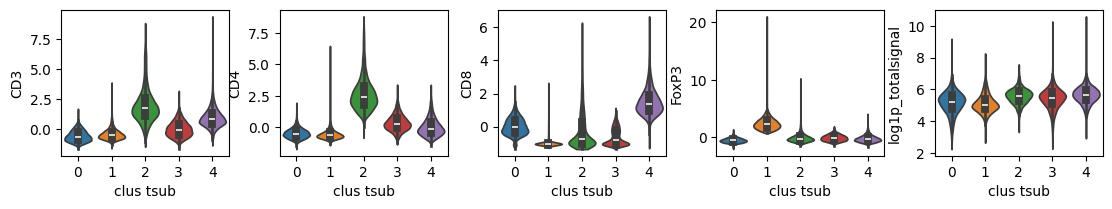

In [23]:
# vln markers/batch

with rc_context({"figure.figsize": (3,2)}):
    sc.pl.violin(adata_t, ['CD3','CD4','CD8','FoxP3','log1p_totalsignal'],
                 groupby='clus_tsub',stripplot=False,layer='Xpc_totsig_log1p_combat',inner="box")

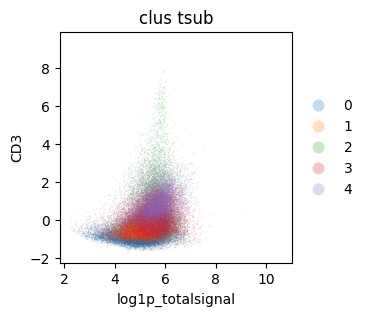

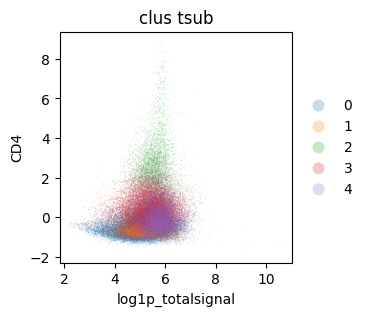

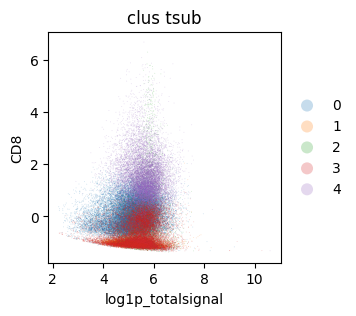

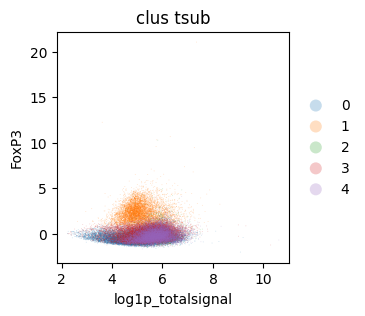

In [24]:
x='log1p_totalsignal'
#x='CD3'
#y='FoxP3'
layer='Xpc_totsig_log1p_combat'
for y in ['CD3','CD4','CD8','FoxP3']:
    fig,ax=plt.subplots(figsize=(3,3))
    sc.pl.scatter(adata_t, x=x, y=y, color='clus_tsub', alpha=0.25, layers=layer, ax=ax)

In [ ]:
# remove CD3- cluster (non-T cells)

In [25]:
adata_t = adata_t[adata_t.obs.clus_tsub!='1']

In [ ]:
# CD4/CD8 cluster

In [53]:
df_ = sc.get.obs_df(adata_t, ['CD4','CD8','CD3'], layer='Xpc_totsig_log1p_combat')

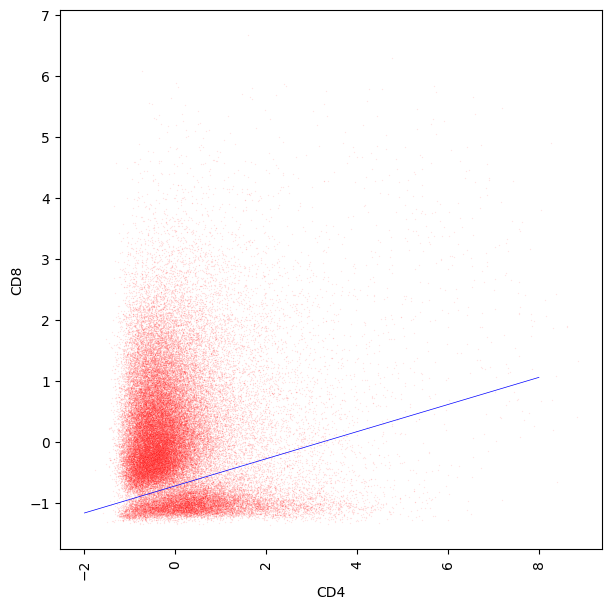

In [94]:
fig,ax=plt.subplots(figsize=(7,7))
#plt.xticks([i/10 for i in range(-20,80,3)])
#plt.yticks([i/10 for i in range(-20,70,3)])
#plt.grid(True)
sns.scatterplot(df_, x='CD4', y='CD8', alpha=0.1, s=1, color='red', ax=ax)
ax.tick_params(axis='x', rotation=90)

x1,y1 = -0.8,-0.9
x2,y2 = 1,-0.5

slope = (y2 - y1) / (x2 - x1)
intercept = y1 - slope * x1
x_extended = np.linspace(-2, 8, 100)
y_extended = slope * x_extended + intercept
plt.plot(x_extended, y_extended, 'b-', linewidth=0.5, label='Extended line')

plt.show()

In [111]:
df_['subset'] = ''
for i_,r_ in df_.iterrows():
    res = (x2 - x1) * (r_['CD8'] - y1) - (y2 - y1) * (r_['CD4'] - x1)
    if res > 0:
        df_.loc[i_,'subset']='CD8'
    else:
        df_.loc[i_,'subset']='CD4'

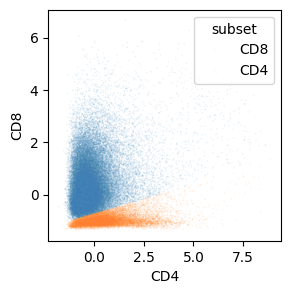

In [123]:
fig,ax=plt.subplots(figsize=(3,3))
sns.scatterplot(df_, x='CD4', y='CD8', hue='subset', alpha=0.1, s=1, ax=ax)
plt.show()

In [122]:
adata_t.obs['subset'] = df_['subset'].tolist()

In [482]:
adata_t.write('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_t.h5ad',compression='gzip')

### Re-psuedobulking, re-clustering - CD8+

Aiming for:
* CD8 Tmem
* CD8 GZMB Tmem
* CD8 Tnaive
* CD8 Tex

In [255]:
adata_CD8 = adata_t[adata_t.obs.subset=='CD8']
adata_CD8.n_obs/adata_t.n_obs*100

77.25124666589353

In [256]:
adata.var_names

Index(['Ki-67', 'aSMA', 'CCR4', 'CD14', 'TIM-3', 'CD16', 'CD163', 'CD11b',
       'PD-L1', 'CD31', 'CD45', 'BCMA', 'CD11c', 'FoxP3', 'CD4', 'Granzyme_K',
       'CD68', 'CD117', 'CD20', 'CD8', 'CCR6', 'CD56', 'PD-1', 'CD138',
       'Granzyme_B', 'CD127', 'pSTAT1', 'CD3', 'CD27', 'TIGIT', 'CCR7',
       'HLA-DR', 'CD45RO', 'Histone_H3', 'ICSK1', 'ICSK2'],
      dtype='object')

In [363]:
markers_CD8 = ['CD45RO','CD127','Granzyme_B','PD-1','TIM-3'] #'TIGIT','CCR7' #batch...

In [258]:
# Expression prep - scaling
adata_CD8.layers['Xpc_totsig_log1p_combat_scaled'] = sc.pp.scale(adata_CD8.layers['Xpc_totsig_log1p_combat'])
adata_CD8.obsm['Xpc_totsig_log1p_combat_scaled'] = adata_CD8[:,markers_].layers['Xpc_totsig_log1p_combat_scaled']

In [128]:
### KNN pseudobulk approach

In [260]:
adata_in = adata_CD8

In [261]:
exp, cell2clus = knn_psuedobulk(adata_in.obsm['Xpc_totsig_log1p_combat_scaled'], nclus=1000)

In [262]:
pd.Series(cell2clus).to_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-CD8.csv')

In [263]:
adata_in.obs['cell2clus'] = cell2clus

In [264]:
import anndata as ad

adata_t_pb = ad.AnnData(X=exp, obs=pd.DataFrame(index=list(range(len(np.unique(cell2clus))))))
adata_t_pb.var =  adata_in[:,markers_].var.copy()
adata_t_pb

AnnData object with n_obs × n_vars = 1000 × 7

In [273]:
sc.pp.neighbors(adata_t_pb,random_state=12345)
sc.tl.leiden(adata_t_pb)
sc.tl.leiden(adata_t_pb, resolution=0.5, key_added='leiden_0.5')
adata_t_pb.obsm['X_umap'] = make_umap(adata_t_pb.X)

In [266]:
cell2clus_cohort = adata_in.obs[['cell2clus','cohort']].value_counts().reset_index()\
.pivot(index='cell2clus',columns='cohort',values='count').fillna(0).rename_axis(None)
cell2clus_cohort['prop_og'] = cell2clus_cohort['og']/(cell2clus_cohort['og']+cell2clus_cohort['validation'])

adata_t_pb.obs = adata_t_pb.obs.join(cell2clus_cohort[['prop_og']])

adata_t_pb.obs = adata_t_pb.obs.join(pd.Series(cell2clus).value_counts())
adata_t_pb.obs['log10_count'] = np.log10(adata_t_pb.obs['count'])

adata_t_pb.obs = adata_t_pb.obs.join(adata.obs[['cell2clus','log1p_totalsignal']].groupby('cell2clus').mean())

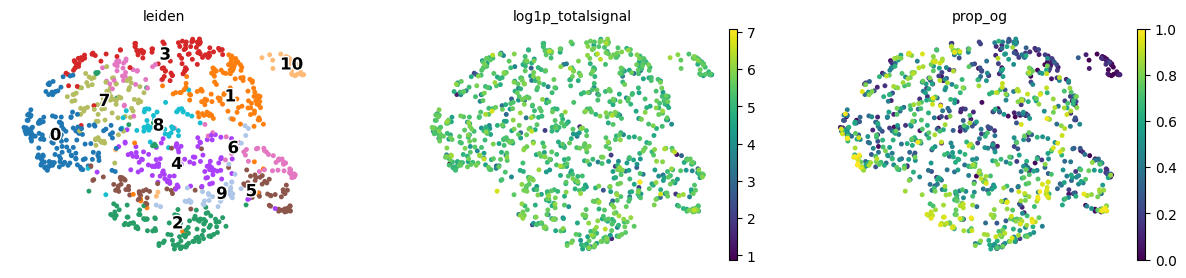

In [441]:
with rc_context({"figure.figsize": (4,3),"axes.titlesize": 10}):
    sc.pl.umap(adata_CD8_pb, color=['leiden','log1p_totalsignal','prop_og'], legend_loc='on data', layer='X_scaled',  ##'log10_count','log1p_totalsignal'
        cmap='viridis', legend_fontsize=12, legend_fontoutline=2, frameon=False, s=50, ncols=3)

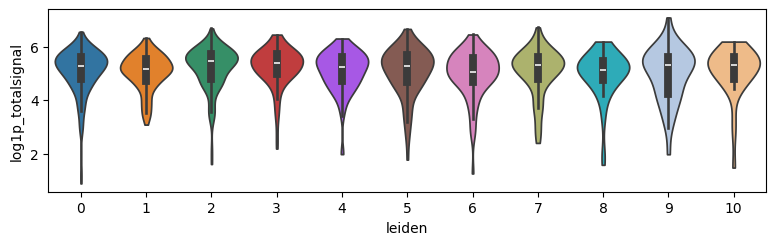

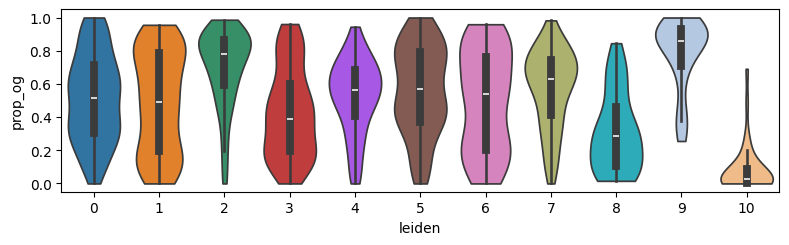

In [331]:
# vln signal/batch
clus_='leiden'
with rc_context({"figure.figsize": (8, 2.5)}):
    for i in ['log1p_totalsignal','prop_og']: ##,'CD3','CD8','CD4','FoxP3']: 
        sc.pl.violin(adata_t_pb,i,groupby=clus_,stripplot=False,inner="box")

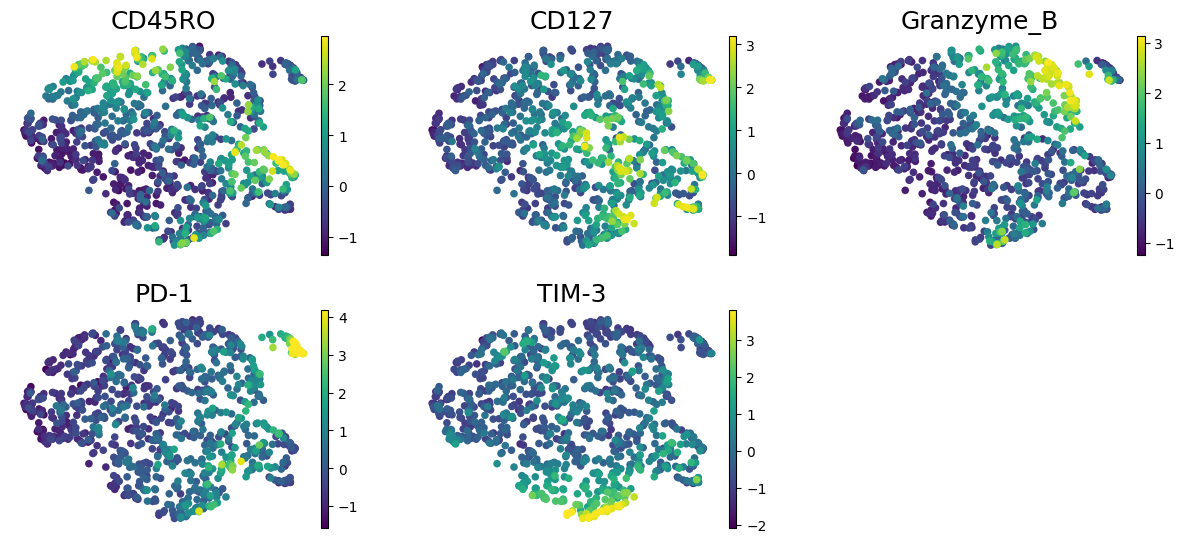

In [282]:
# Pheno umap

with rc_context({"figure.figsize": (4,3),"axes.titlesize": 18}):
    sc.pl.umap(adata_t_pb, color=markers_CD8, legend_loc='right', legend_fontsize=10, legend_fontoutline=2, 
               cmap='viridis', frameon=False, ncols=3)

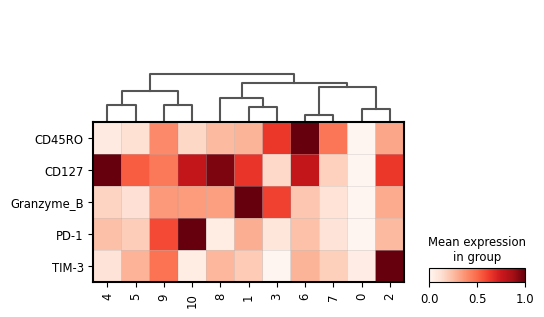

In [280]:
# Pheno hm
clus_='leiden'
sc.pl.matrixplot(adata_t_pb, markers_CD8, clus_, dendrogram=True, cmap="Reds",swap_axes=True,standard_scale='var')

In [438]:
# putative naming
renames_=['CD8_Other','CD8_GZMB','CD8_Tex','CD8_GZMB','CD8_naive','CD8_naive','CD8_Tmem','CD8_Tmem','CD8_naive','CD8_Tex','CD8_Tex']
renames_=dict(zip(list(range(adata_t_pb.obs.leiden.nunique())),renames_))

In [439]:
adata_CD8_pb.obs['ph'] = [renames_[int(i)] for i in adata_CD8_pb.obs['leiden']]

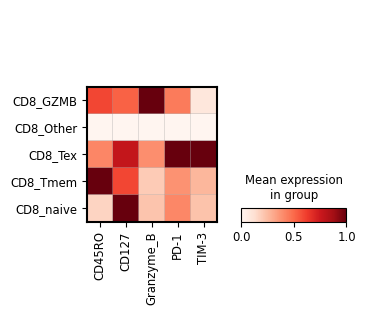

In [440]:
# Pheno hm
clus_='ph'
sc.pl.matrixplot(adata_CD8_pb, markers_CD8, clus_, dendrogram=False, cmap="Reds",swap_axes=False,standard_scale='var')

In [349]:
adata_in.obs = adata_in.obs.merge(
    adata_t_pb.obs[['ph']].reset_index().rename({'index':'cell2clus'},axis=1)
)

In [358]:
adata_CD8_pb = adata_t_pb.copy()

In [473]:
adata_CD8_pb.write('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-CD8.h5ad',compression='gzip')

### Re-psuedobulking, re-clustering - CD4+

Aiming for:
* CD4 Tex
* CD4 Tmem
* CD4 Treg
* CD4 naive
* CD4 Th17

In [359]:
adata_CD4 = adata_t[adata_t.obs.subset=='CD4']
adata_CD4.n_obs/adata_t.n_obs*100

22.748753334106457

In [360]:
adata.var_names

Index(['Ki-67', 'aSMA', 'CCR4', 'CD14', 'TIM-3', 'CD16', 'CD163', 'CD11b',
       'PD-L1', 'CD31', 'CD45', 'BCMA', 'CD11c', 'FoxP3', 'CD4', 'Granzyme_K',
       'CD68', 'CD117', 'CD20', 'CD8', 'CCR6', 'CD56', 'PD-1', 'CD138',
       'Granzyme_B', 'CD127', 'pSTAT1', 'CD3', 'CD27', 'TIGIT', 'CCR7',
       'HLA-DR', 'CD45RO', 'Histone_H3', 'ICSK1', 'ICSK2'],
      dtype='object')

In [362]:
markers_CD4 = ['CD45RO','CD127','Granzyme_B','PD-1','FoxP3','CCR6'] #'TIGIT','CCR7' #batch...

In [364]:
# Expression prep - scaling
adata_CD4.layers['Xpc_totsig_log1p_combat_scaled'] = sc.pp.scale(adata_CD4.layers['Xpc_totsig_log1p_combat'])
adata_CD4.obsm['Xpc_totsig_log1p_combat_scaled'] = adata_CD4[:,markers_].layers['Xpc_totsig_log1p_combat_scaled']

In [128]:
### KNN pseudobulk approach

In [366]:
adata_in = adata_CD4

In [367]:
exp, cell2clus = knn_psuedobulk(adata_in.obsm['Xpc_totsig_log1p_combat_scaled'], nclus=1000)

In [368]:
pd.Series(cell2clus).to_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-CD4.csv')

In [369]:
adata_in.obs['cell2clus'] = cell2clus

In [370]:
import anndata as ad

adata_t_pb = ad.AnnData(X=exp, obs=pd.DataFrame(index=list(range(len(np.unique(cell2clus))))))
adata_t_pb.var =  adata_in[:,markers_].var.copy()
adata_t_pb

AnnData object with n_obs × n_vars = 1000 × 7

In [371]:
sc.pp.neighbors(adata_t_pb,random_state=12345)
sc.tl.leiden(adata_t_pb)
sc.tl.leiden(adata_t_pb, resolution=0.5, key_added='leiden_0.5')
adata_t_pb.obsm['X_umap'] = make_umap(adata_t_pb.X)

In [372]:
cell2clus_cohort = adata_in.obs[['cell2clus','cohort']].value_counts().reset_index()\
.pivot(index='cell2clus',columns='cohort',values='count').fillna(0).rename_axis(None)
cell2clus_cohort['prop_og'] = cell2clus_cohort['og']/(cell2clus_cohort['og']+cell2clus_cohort['validation'])

adata_t_pb.obs = adata_t_pb.obs.join(cell2clus_cohort[['prop_og']])

adata_t_pb.obs = adata_t_pb.obs.join(pd.Series(cell2clus).value_counts())
adata_t_pb.obs['log10_count'] = np.log10(adata_t_pb.obs['count'])

adata_t_pb.obs = adata_t_pb.obs.join(adata.obs[['cell2clus','log1p_totalsignal']].groupby('cell2clus').mean())

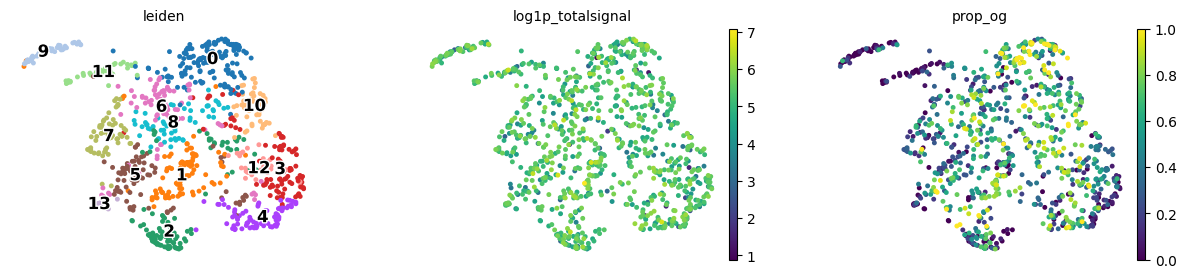

In [432]:
with rc_context({"figure.figsize": (4,3),"axes.titlesize": 10}):
    sc.pl.umap(adata_CD4_pb, color=['leiden','log1p_totalsignal','prop_og'], legend_loc='on data', layer='X_scaled',  ##'log10_count','log1p_totalsignal'
        cmap='viridis', legend_fontsize=12, legend_fontoutline=2, frameon=False, s=50, ncols=3)

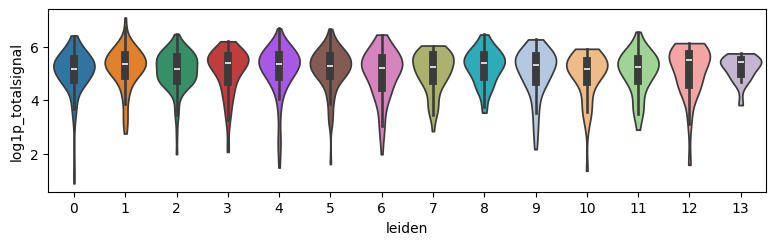

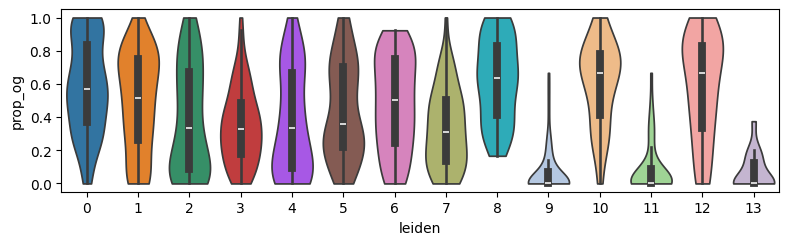

In [374]:
# vln signal/batch
clus_='leiden'
with rc_context({"figure.figsize": (8, 2.5)}):
    for i in ['log1p_totalsignal','prop_og']: ##,'CD3','CD8','CD4','FoxP3']: 
        sc.pl.violin(adata_t_pb,i,groupby=clus_,stripplot=False,inner="box")

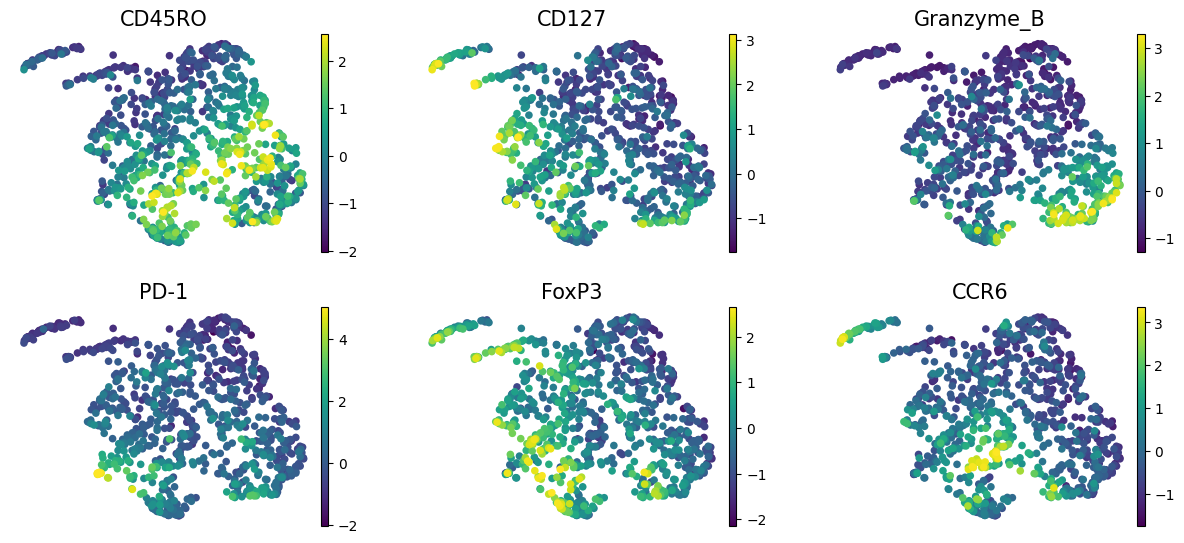

In [375]:
# Pheno umap

with rc_context({"figure.figsize": (4,3),"axes.titlesize": 15}):
    sc.pl.umap(adata_t_pb, color=markers_CD4, legend_loc='right', legend_fontsize=10, legend_fontoutline=2, 
               cmap='viridis', frameon=False, ncols=3)

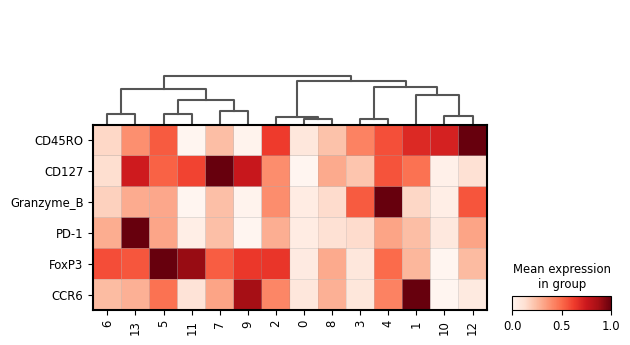

In [377]:
# Pheno hm
clus_='leiden'
sc.pl.matrixplot(adata_t_pb, markers_CD4, clus_, dendrogram=True, cmap="Reds",swap_axes=True,standard_scale='var')

Aiming for:
* CD4 Tex
* CD4 Tmem
* CD4 Treg
* CD4 naive
* CD4 Th17

In [433]:
# putative naming
renames_=['CD4_Other','CD4_CCR6','CD4_Treg','CD4_GZMB','CD4_GZMB',#4
          'CD4_Treg','CD4_Treg','CD4_Tn','CD4_Tn','CD4_CCR6',#9
          'CD4_Tmem','CD4_Treg','CD4_GZMB','CD4_Tex']
renames_=dict(zip(list(range(adata_t_pb.obs.leiden.nunique())),renames_))

In [461]:
adata_t_pb.obs['ph'] = [renames_[int(i)] for i in adata_t_pb.obs['leiden']]

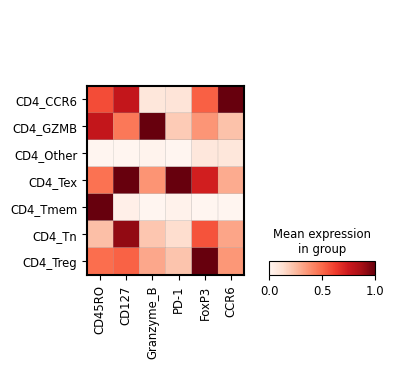

In [460]:
# Pheno hm
clus_='ph'
sc.pl.matrixplot(adata_t_pb, markers_CD4, clus_, dendrogram=False, cmap="Reds",swap_axes=False,standard_scale='var')

In [437]:
adata_CD4_pb = adata_t_pb.copy()

In [474]:
adata_CD4_pb.write('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-CD4.h5ad',compression='gzip')

## Clustering: mixed myeloid

In [ ]:
# Myeloid
#contains mix of CD45only; true myeloid, Mac, other unknowns

Aiming for:
* M1/M2 Mac
* "Myeloid/MDSC"
* MoDC
* Mono

In [391]:
adata_mye = adata[adata.obs.cell2clus.isin(adata_pb[adata_pb.obs.lineage=='Myeloid'].obs_names)]
adata_mye.layers['Xpc_totsig_log1p_combat_scaled'] = sc.pp.scale(adata_mye.layers['Xpc_totsig_log1p_combat'])
adata_mye.n_obs/adata.n_obs*100

41.1768486888194

In [394]:
adata.var_names

Index(['Ki-67', 'aSMA', 'CCR4', 'CD14', 'TIM-3', 'CD16', 'CD163', 'CD11b',
       'PD-L1', 'CD31', 'CD45', 'BCMA', 'CD11c', 'FoxP3', 'CD4', 'Granzyme_K',
       'CD68', 'CD117', 'CD20', 'CD8', 'CCR6', 'CD56', 'PD-1', 'CD138',
       'Granzyme_B', 'CD127', 'pSTAT1', 'CD3', 'CD27', 'TIGIT', 'CCR7',
       'HLA-DR', 'CD45RO', 'Histone_H3', 'ICSK1', 'ICSK2'],
      dtype='object')

In [412]:
markers_mye = ['CD14','CD16','CD163','CD11b','CD11c','CD68','HLA-DR',] #PD-L1=batch

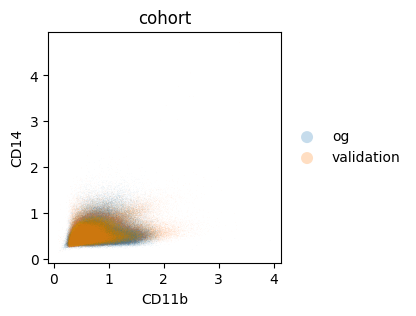

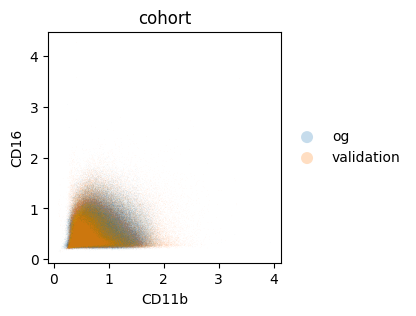

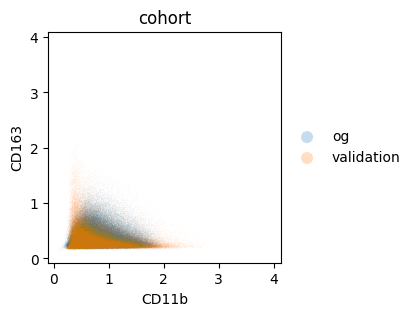

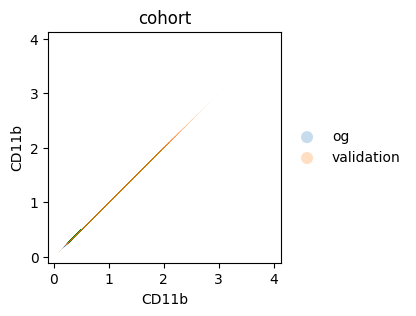

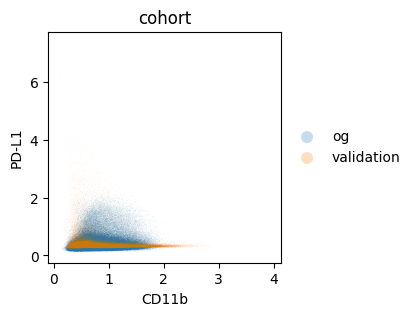

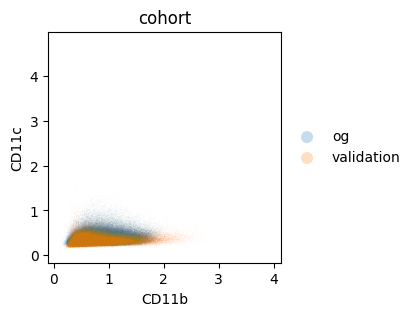

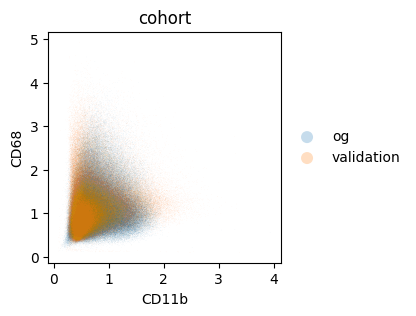

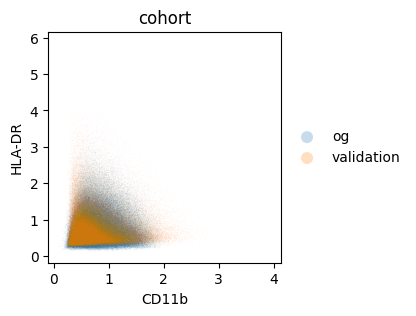

In [411]:
for m in markers_mye:
    fig,ax=plt.subplots(figsize=(3,3))
    sc.pl.scatter(adata_mye, x='CD11b', y=m, color='cohort', alpha=0.25, layers=layer, ax=ax)

In [413]:
# Expression prep - scaling
adata_mye.obsm['Xpc_totsig_log1p_combat_scaled'] = adata_mye[:,markers_mye].layers['Xpc_totsig_log1p_combat_scaled']

In [128]:
### KNN pseudobulk approach

In [414]:
adata_in = adata_mye

In [415]:
exp, cell2clus = knn_psuedobulk(adata_in.obsm['Xpc_totsig_log1p_combat_scaled'], nclus=1000)

In [416]:
pd.Series(cell2clus).to_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-mye.csv')

In [417]:
adata_in.obs['cell2clus'] = cell2clus

In [418]:
import anndata as ad

adata_m_pb = ad.AnnData(X=exp, obs=pd.DataFrame(index=list(range(len(np.unique(cell2clus))))))
adata_m_pb.var =  adata_in[:,markers_mye].var.copy()
adata_m_pb

AnnData object with n_obs × n_vars = 1000 × 7

In [419]:
sc.pp.neighbors(adata_m_pb,random_state=12345)
sc.tl.leiden(adata_m_pb)
sc.tl.leiden(adata_m_pb, resolution=0.5, key_added='leiden_0.5')
sc.tl.leiden(adata_m_pb, resolution=1.5, key_added='leiden_1.5')
adata_m_pb.obsm['X_umap'] = make_umap(adata_m_pb.X)

In [420]:
cell2clus_cohort = adata_in.obs[['cell2clus','cohort']].value_counts().reset_index()\
.pivot(index='cell2clus',columns='cohort',values='count').fillna(0).rename_axis(None)
cell2clus_cohort['prop_og'] = cell2clus_cohort['og']/(cell2clus_cohort['og']+cell2clus_cohort['validation'])

adata_m_pb.obs = adata_m_pb.obs.join(cell2clus_cohort[['prop_og']])

adata_m_pb.obs = adata_m_pb.obs.join(pd.Series(cell2clus).value_counts())
adata_m_pb.obs['log10_count'] = np.log10(adata_m_pb.obs['count'])

adata_m_pb.obs = adata_m_pb.obs.join(adata.obs[['cell2clus','log1p_totalsignal']].groupby('cell2clus').mean())

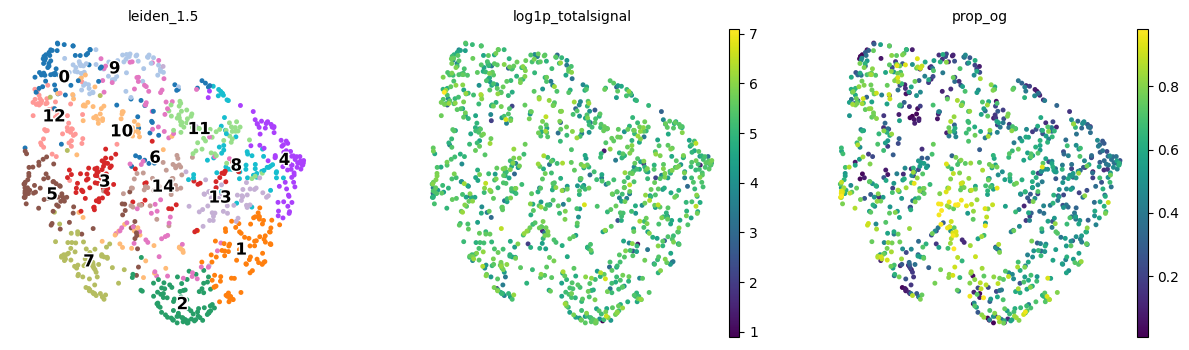

In [447]:
with rc_context({"figure.figsize": (4,4),"axes.titlesize": 10}):
    sc.pl.umap(adata_m_pb, color=['leiden_1.5','log1p_totalsignal','prop_og'], legend_loc='on data', layer='X_scaled',  ##'log10_count','log1p_totalsignal'
        cmap='viridis', legend_fontsize=12, legend_fontoutline=2, frameon=False, s=50, ncols=3)

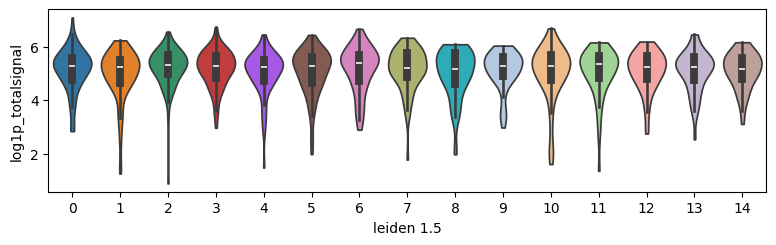

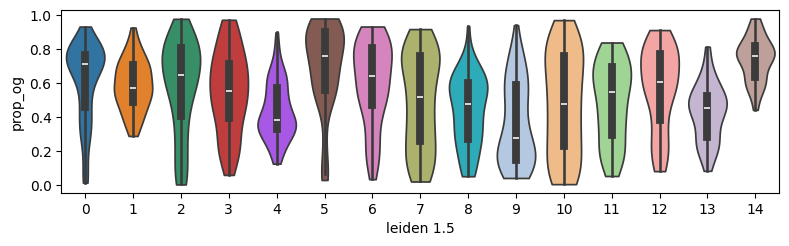

In [445]:
# vln signal/batch
clus_='leiden_1.5'
with rc_context({"figure.figsize": (8, 2.5)}):
    for i in ['log1p_totalsignal','prop_og']: ##,'CD3','CD8','CD4','FoxP3']: 
        sc.pl.violin(adata_m_pb,i,groupby=clus_,stripplot=False,inner="box")

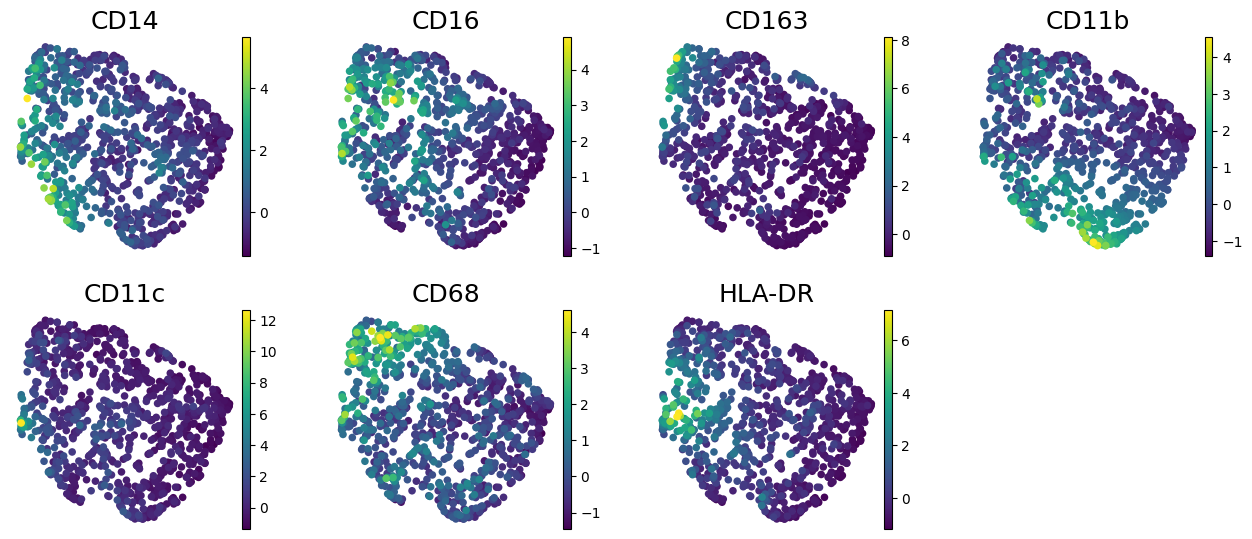

In [451]:
# Pheno umap

with rc_context({"figure.figsize": (3,3),"axes.titlesize": 18}):
    sc.pl.umap(adata_m_pb, color=markers_mye, legend_loc='right', legend_fontsize=10, legend_fontoutline=2, 
               cmap='viridis', frameon=False, ncols=4)

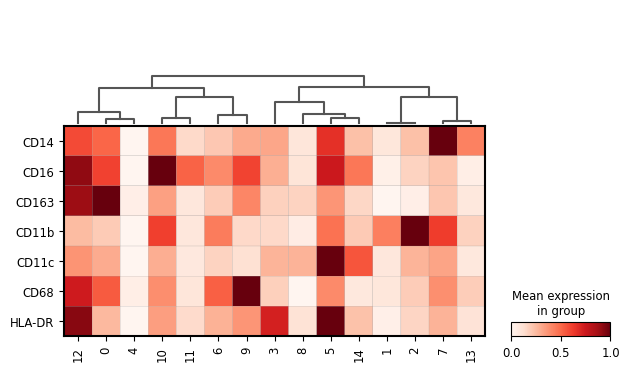

In [449]:
# Pheno hm
clus_='leiden_1.5'
sc.pl.matrixplot(adata_m_pb, markers_mye, clus_, dendrogram=True, cmap="Reds",swap_axes=True,standard_scale='var')

11

In [462]:
# putative naming
renames_=['Mac_M1','Mye_other','Mye_other','Mye_HLADR',
          'Mye_other','DC','Mac_M2','Mono_CD14',
          'Mye_other','Mac_M2','Mono_CD16','Mono_CD16',
          'Mac_M1','Mono_CD16','Mye_other']

renames_=dict(zip(list(range(adata_m_pb.obs['leiden_1.5'].nunique())),renames_))

In [463]:
adata_m_pb.obs['ph'] = [renames_[int(i)] for i in adata_m_pb.obs['leiden_1.5']]

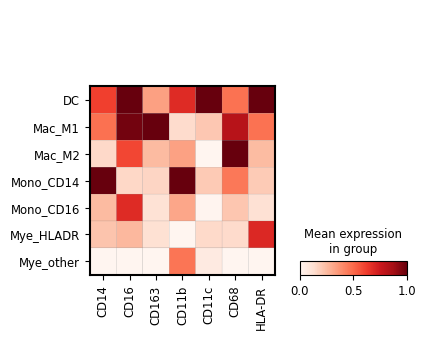

In [466]:
# Pheno hm
clus_='ph'
sc.pl.matrixplot(adata_m_pb, markers_mye, clus_, dendrogram=False, cmap="Reds",swap_axes=False,standard_scale='var')

In [475]:
adata_m_pb.write('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-mye.h5ad',compression='gzip')

## Output

* major_cell_type
* minor_cell_type
* functional

In [191]:
adata_ = adata.copy()

#adata.write('')

In [192]:
adata_.obs.shape[0]

1384630

In [193]:
obs_og_all =  sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/in/full_data-no_uns.h5ad').obs

In [194]:
obs_og = sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/in/full_data-no_uns.h5ad').obs
obs_og = obs_og[['sample_id','Cell_ID']]

In [195]:
obs_og.shape[0]

1409942

In [196]:
adata_pb = sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-allcells.h5ad')
labels = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/pheno-allcells.csv')
labels.leiden_2=labels.leiden_2.astype(str)
adata_pb.obs = adata_pb.obs.drop(['lineage','pheno','notes'],axis=1)
adata_pb.obs = adata_pb.obs.merge(labels)

In [197]:
adata.obs['cell2clus'] = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-allcells.csv',index_col=0).astype(str).iloc[:,0].tolist()
obs_all = adata.obs.merge(
    adata_pb.obs[['lineage','pheno']].reset_index().rename({'index':'cell2clus'},axis=1)
)[['sample_id','Cell_ID','lineage','pheno']]

In [198]:
obs_t = sc.read("/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_t.h5ad").obs

In [199]:
obs_ = obs_t[obs_t.subset=='CD8']
obs_['cell2clus'] = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-CD8.csv',index_col=0).iloc[:,0].astype(str).tolist()
obs_ = obs_.merge(
    sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-CD8.h5ad').obs[['ph']].reset_index().rename({'index':'cell2clus'},axis=1)
)
obs_cd8 = obs_[['sample_id','Cell_ID','ph']].copy()

In [200]:
obs_ = obs_t[obs_t.subset=='CD4']
obs_['cell2clus'] = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-CD4.csv',index_col=0).iloc[:,0].astype(str).tolist()
obs_ = obs_.merge(
    sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-CD4.h5ad').obs[['ph']].reset_index().rename({'index':'cell2clus'},axis=1)
)
obs_cd4 = obs_[['sample_id','Cell_ID','ph']].copy()

In [201]:
adata.obs['lineage']=obs_all['lineage'].tolist()
obs_m = adata[adata.obs.lineage=='Myeloid'].obs

In [202]:
obs_ = obs_m.copy()
obs_['cell2clus'] = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/cell2clus-mye.csv',index_col=0).iloc[:,0].astype(str).tolist()
obs_ = obs_.merge(
    sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/adata_pb-mye.h5ad').obs[['ph']].reset_index().rename({'index':'cell2clus'},axis=1)
)
obs_mye = obs_[['sample_id','Cell_ID','ph']].copy()

In [203]:
obs_out = obs_og.merge(obs_all[['sample_id','Cell_ID','lineage']], how='outer')

In [204]:
obs_out.lineage = obs_out.lineage.fillna('Adipocyte')

In [205]:
obs_out = obs_out.merge(pd.concat([obs_cd4,obs_cd8,obs_mye],axis=0), how='outer')

In [206]:
# issue: the log1p_totalsignal cells
# rename to Lin-

adata_ = sc.read('/mnt/disks/data/imc/CancerCellRev/batch_repheno/in/full_data-no_uns.h5ad') #`.uns['spatial']` removed
adata_ = adata_[adata_.obs.major_cell_type!='Adipocyte',]
adata_.obs['log1p_totalsignal'] = np.log1p(adata_.X.sum(axis=1))
log1p_totalsignal__thr = 2.5 #confirmed on umap
min_signal_obs = adata_[adata_.obs['log1p_totalsignal']<=2.5].obs[['sample_id','Cell_ID']]
##del adata_

min_signal_obs['min_signal'] = True

obs_out = obs_out.merge(min_signal_obs,how='outer')

obs_out['lineage'] = np.where(obs_out['min_signal'].fillna(False),'Lin-',obs_out['lineage'])
obs_out['ph'] = np.where(obs_out['min_signal'].fillna(False),'Lin-',obs_out['ph'])
obs_out = obs_out.drop('min_signal',axis=1)

In [215]:
# CD138+ to PC

df_PC_Bcell_gating = pd.read_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/df_PC_Bcell_gating.csv')[['sample_id','Cell_ID','lineage2']]
obs_out = obs_out.merge(df_PC_Bcell_gating, how='outer')

obs_out['lineage'] = obs_out.lineage2.fillna(obs_out.lineage)
obs_out = obs_out.drop('lineage2',axis=1)

In [245]:
# Ki-67+
exp_ = adata[:,'Ki-67'].layers['Xpc_totsig_log1p_combat'].ravel()
adata.obs['Ki67_pos'] = (exp_ > np.mean(exp_)+np.std(exp_)).astype(str)

obs_out = obs_out.merge(adata.obs[['sample_id','Cell_ID','Ki67_pos']], how='outer')
obs_out.Ki67_pos = obs_out.Ki67_pos.fillna(False)

In [248]:
# Fill in ph with lineage

obs_out.ph = obs_out.ph.fillna(obs_out.lineage)

In [263]:
# Manuel fixes

# Remove lineage==T, Tsubclus==Artifact (CD3-CD8-CD4- FoxP3+)
obs_out.lineage = np.where(obs_out.ph=='T','Artifact',obs_out.lineage)
obs_out.ph = np.where(obs_out.ph=='T','Artifact',obs_out.ph)

# Mis-labeled PC/Lin-
obs_out.lineage = np.where( (obs_out.lineage=='Myeloma') & (obs_out.ph=='Lin-'), 'Lin-', obs_out.lineage )

In [275]:
#sns.heatmap(pd.crosstab(obs_out.ph,obs_out.lineage)>0)

In [278]:
obs_out.to_csv('/mnt/disks/data/imc/CancerCellRev/batch_repheno/out/v2_pheno-labels_update3.csv')